C:\Users\tspro\AppData\Local\Temp\ipykernel_44068\193316363.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("Pantheon_SH0ES.dat", delim_whitespace=True)


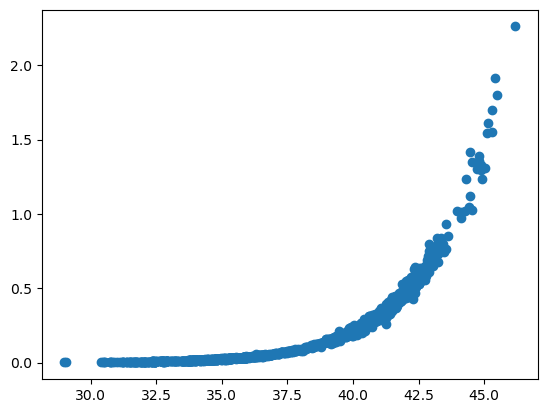

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
data = pd.read_csv("Pantheon_SH0ES.dat", delim_whitespace=True)


z = data["zHD"]
d = data["MU_SH0ES"]
sigma = data["MU_SH0ES_ERR_DIAG"]

plt.scatter(d,z)

In [61]:
c = 3e5
H_0 = 70

omega_m = 0.2
omega_lambda = 1-omega_m

def H(h): #using h as dummy variable for z
    return H_0*np.sqrt(omega_m*(1+h)**3+omega_lambda)

def d_L(h):
    integral, _ = quad(lambda z_prime: 1.0 / H(z_prime), 0, h)
    return (1 + h) * c * integral #returns in Mpc


def d_model(h):
    return 5 * np.log10(d_L(h)) + 25
dL_vals = np.array([d_model(h) for h in z])




In [116]:
#for loop for chi^2
romega_m = np.linspace(0,1,1000)
intvals = np.linspace(0,999,1000, dtype=int)
omega_m = 0

chi2vals = []
for i in intvals:
    

        
    omega_lambda = 1- romega_m[i]
    def H(h, omega_m): #using h as dummy variable for z
        return H_0*np.sqrt(omega_m*(1+h)**3+omega_lambda)

    def d_L(h, omega_m):
        integral, _ = quad(lambda z_prime: 1.0 / H(z_prime, omega_m), 0, h)
        return (1 + h) * c * integral #returns in Mpc
    

    def d_model(h, omega_m):
        return 5 * np.log10(d_L(h, omega_m)) + 25
    dL_vals = np.array([d_model(h, omega_m) for h in z])
        
    redchi2 = (np.sum(((d-dL_vals)/ sigma)**2))/1699
    chi2vals.append(redchi2)

    omega_m = omega_m + 0.001






In [121]:

good_omega = []
for i in intvals:
    if chi2vals[i] > 0.998 and chi2vals[i] < 1.002:
        good_omega.append(romega_m[i])    
print(good_omega)

[np.float64(0.18618618618618618)]


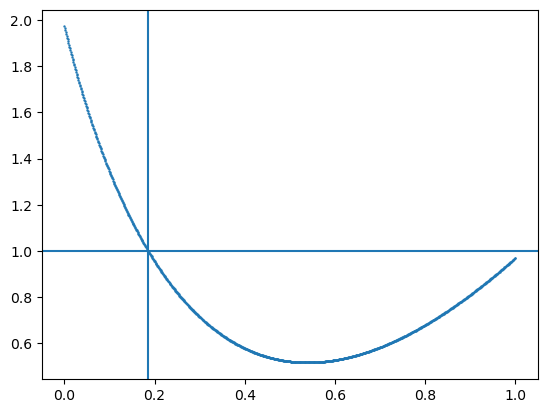

In [123]:
#reduced chi vs omega_m

plt.scatter(romega_m, chi2vals, s = 0.5)
plt.axhline(y = 1) 
plt.axvline(x = 0.186)

In [ ]:
plt.scatter(d,z, color = 'red', label = "Data", s = 4)
plt.plot(dL_vals, z, color = 'blue', label=f"Model ($\\Omega_m$={omega_m}, $\\Omega_\\Lambda$={omega_lambda})")
plt.xlabel("Distance Modulus (mag)")
plt.ylabel("Redshift")
plt.legend()
plt.show()
